In [8]:
import Pyro4
from qick import QickConfig
Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION=4
from data_fitting.module_fitzcu import *
ns_host = "192.168.20.46"
ns_port = 8888
proxy_name = "myqick"

ns = Pyro4.locateNS(host=ns_host, port=ns_port)
soc = Pyro4.Proxy(ns.lookup(proxy_name))
soccfg = QickConfig(soc.get_cfg())
print(soccfg)

import Labber

from qick import *


QICK library version mismatch: 0.2.302 remote (the board), 0.2.309 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


QICK running on ZCU216, software version 0.2.302

Firmware configuration (built Mon Aug 21 11:09:34 2023):

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	7 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 65536 samples (9.524 us)
		fs=6881.280 MHz, fabric=430.080 MHz, 32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 0 is 0_230, on JHC3
	1:	axis_signal_gen_v6 - envelope memory 65536 samples (9.524 us)
		fs=6881.280 MHz, fabric=430.080 MHz, 32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 1 is 1_230, on JHC4
	2:	axis_signal_gen_v6 - envelope memory 65536 samples (9.524 us)
		fs=6881.280 MHz, fabric=430.080 MHz, 32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 2 is 2_230, on JHC3
	3:	axis_signal_gen_v6 - envelope memory 65536 samples (9.524 us)
		fs=6881.280 MHz, fabric=430.080 MHz, 32-bit DDS, range=6881.280 MHz
		DAC tile 2, blk 3 is 3_230, on JHC4
	4:	axis_signal_gen_v6 - envelope memory 65536 samples (9.524 us)
		fs=6881.280 MHz, fabric=430.080 MH

# BackBone

In [3]:
from os.path import isdir, join
import os
import requests
from datetime import datetime
from numpy import pi

def hdf5_generator(
        filepath: str,
        x_info:dict, z_info:dict, 
        y_info:dict = None, comment = None, tag = None):
    
    zdata = z_info['values']
    z_info.update({'complex': True, 'vector': False})
    log_channels = [z_info]
    step_channels = list(filter(None, [x_info, y_info]))

    fObj = Labber.createLogFile_ForData(filepath, log_channels, step_channels)
    if y_info:
        for trace in zdata:
            fObj.addEntry({z_info['name']: trace})
    else:
        fObj.addEntry({z_info['name']: zdata})

    if comment: fObj.setComment(comment)
    if tag: fObj.setTags(tag)
    
def upload_file2server(filepath: str, server_ip: str, port: int):
    url = f'http://{server_ip}:{port}/upload'  
    with open(filepath, 'rb') as file:
        files = {'file': (filepath, file)}
        response = requests.post(url, files=files)

    print(response.text)
    
def create_labber_datafolder(dest_path: str):
    if not isdir(dest_path):
        raise ValueError('Invalid directory')
    yy, mm, dd = datetime.today().strftime('%Y-%m-%d').split('-')
    save_path = join(dest_path, f'{yy}/{mm}/Data_{mm}{dd}')
    if not isdir(save_path):
        os.makedirs(save_path)
    return save_path

hostip = '192.168.10.80' # cmd-> ipconfig -> ipv4 #controling computer
client = Labber.connectToServer(hostip, timeout=86400)

data_path = "/home/xilinx/jupyter_notebooks/nthu/sinica-5q/Jay/Database"
database_path = create_labber_datafolder(os.path.join(data_path))

# OneTone

In [3]:
class SingleToneSpectroscopyProgram(AveragerProgram):
    def initialize(self):
        cfg=self.cfg   
        self.declare_gen(ch=cfg["res_ch"], nqz=2) #Readout
        for ch in [0,1]: #configure the readout lengths and downconversion frequencies
            self.declare_readout(ch=ch, length=cfg["readout_length"],
                                 freq=cfg["frequency"], gen_ch=cfg["res_ch"])
        
        freq=self.freq2reg(cfg["frequency"], gen_ch=cfg["res_ch"], ro_ch=0)  # convert frequency to dac frequency (ensuring it is an available adc frequency)
        self.set_pulse_registers(ch=cfg["res_ch"], style="const", freq=freq, phase=0, gain=cfg["res_gain"],
                                length=cfg["readout_length"])

        self.synci(200)  # give processor some time to configure pulses
    
    def body(self):
        self.measure(pulse_ch=self.cfg["res_ch"], 
             adcs=[0,1],
             adc_trig_offset=self.cfg["adc_trig_offset"],
             wait=True,
             syncdelay=self.us2cycles(self.cfg["relax_delay"]))     

In [5]:
config={"res_ch":0, # --Fixed
        "ro_chs":0, # --Fixed
        "reps":1, # --Fixed
        "relax_delay":0.0, # --us
        "res_phase":0, # --degrees
        "pulse_style": "const", # --Fixed
        "readout_length":soc.us2cycles(1), 
        "res_gain":30000, 
        "frequency": 3000, # [MHz]
        "adc_trig_offset": soc.us2cycles(0.45),
        "soft_avgs":1
       }



## measure

  0%|          | 0/2001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

c:\Users\SQC\Anaconda3\envs\test\lib\site-packages\scipy\optimize\_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


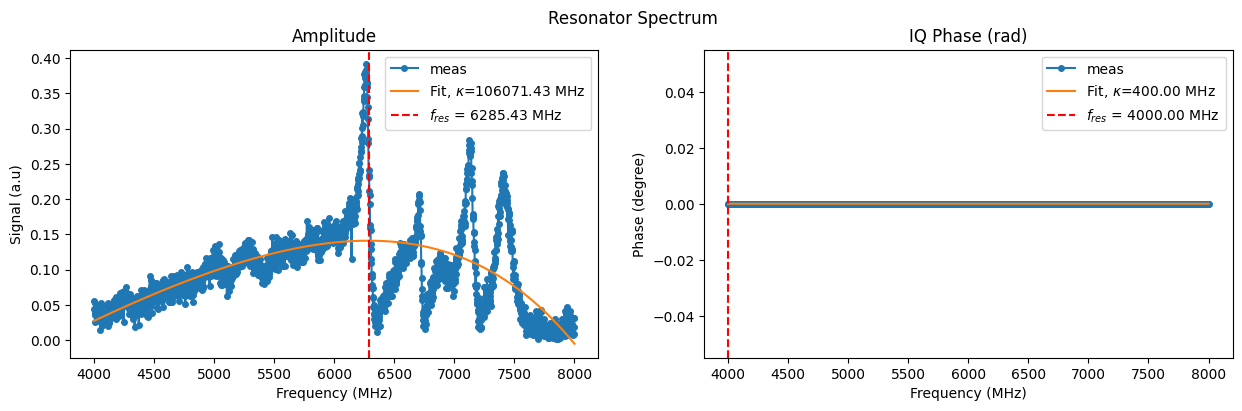

4000.0

In [9]:
from tqdm.notebook  import tqdm
import numpy as np
expt_cfg={"reps":100, "rounds":10,"relax_delay":0,
          "start":4000, "stop":8000, "expts":2001 }
config={**config,**expt_cfg} #combine configs
fpts=np.linspace(expt_cfg["start"], expt_cfg["stop"], expt_cfg["expts"])
config['res_gain'] = 30000
amps=[]
for f in tqdm(fpts):
    config["frequency"]=f
    rspec=SingleToneSpectroscopyProgram(soccfg, config)
    avgi,avgq=rspec.acquire(soc, progress=False)
    amp=np.array(avgi[0][0]+1j*avgq[0][0])
    amps.append(amp)
amps = np.array(amps)

# from module_fitzcu import * 
resonator_analyze(fpts, np.abs(amps), fit=True)


  0%|          | 0/201 [00:00<?, ?it/s]

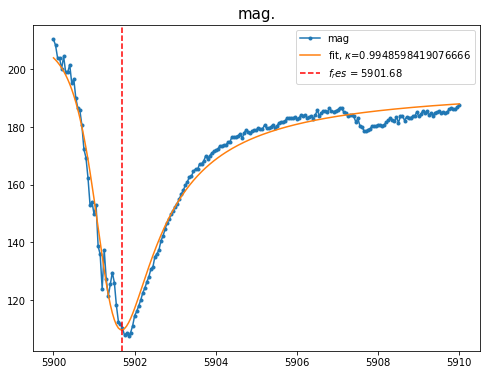

5901.68

In [16]:
config['res_gain'] = 20000
amps=[]
for f in tqdm(fpts):
    config["frequency"]=f
    rspec=SingleToneSpectroscopyProgram(soccfg, config)
    avgi,avgq=rspec.acquire(soc)
    amp=np.array(avgi[0][0]+1j*avgq[0][0])
    amps.append(amp)
amps = np.array(amps)

from module_fitzcu import *
r2=resonator_analyze2(fpts, np.abs(amps), fit=True)
r2

c:\Users\SQC\Anaconda3\envs\test\lib\site-packages\scipy\optimize\_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


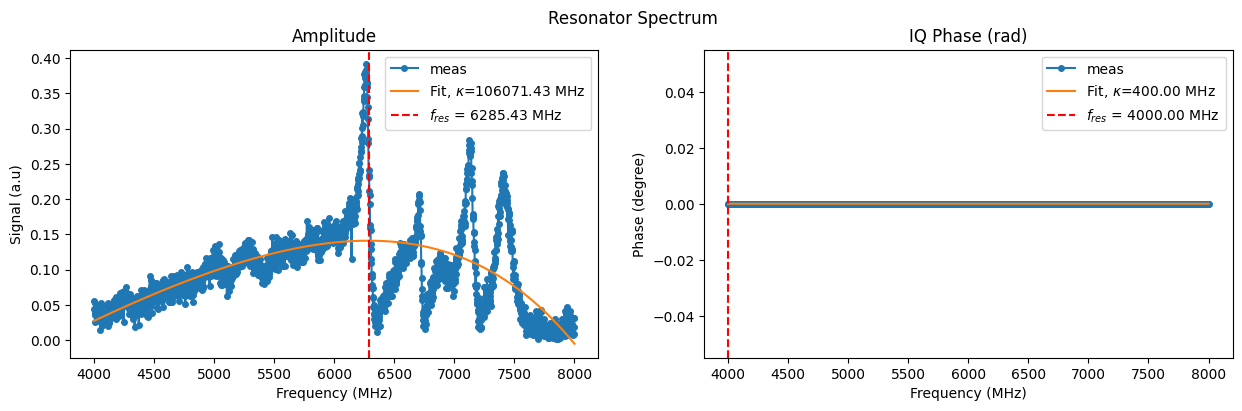

4000.0

In [10]:
resonator_analyze(fpts, np.abs(amps), fit=True)

In [17]:
r-r2

3.719999999999345

## SaveFile

In [11]:
from os.path import isdir, join
import os
import requests
# from datetime import datetime
import datetime
from numpy import pi
import re
import Labber

def hdf5_generator(
        filepath: str,
        x_info:dict, z_info:dict, 
        y_info:dict = None, comment = None, tag = None):
    np.float=float
    np.bool=bool
    zdata = z_info['values']
    z_info.update({'complex': True, 'vector': False})
    log_channels = [z_info]
    step_channels = list(filter(None, [x_info, y_info]))

    fObj = Labber.createLogFile_ForData(filepath, log_channels, step_channels)
    if y_info:
        for trace in zdata:
            fObj.addEntry({z_info['name']: trace})
    else:
        fObj.addEntry({z_info['name']: zdata})

    if comment: fObj.setComment(comment)
    if tag: fObj.setTags(tag)
    


def get_next_filename_labber(dest_path: str, exp_name: str) -> str:
    # make sure dest_path is absolute path
    dest_path = os.path.abspath(dest_path)
    yy, mm, dd = datetime.datetime.today().strftime('%Y-%m-%d').split('-')
    save_path = os.path.join(dest_path, yy, mm, f"Data_{mm}{dd}")
    os.makedirs(save_path, exist_ok=True)

    existing_files = [f for f in os.listdir(save_path) if re.match(
        rf"{re.escape(exp_name)}_\d+\.hdf5", f)]
    next_index = max([int(re.search(r"_(\d+)", f).group(1))
                     for f in existing_files], default=0) + 1

    return os.path.join(save_path, f"{exp_name}_{next_index}")

data_path = r'C:\Users\SQC\Desktop\ZCU\ZCU_Data\2DQ7[01]-rebound'

In [12]:
data_path = data_path
# exp_name = f"resonator flux spec"
exp_name = f"test"

file_path = get_next_filename_labber(data_path, exp_name)

hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Frequency', 'unit': "Hz",
                'values': fpts*1e6},  

        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  amps},
        comment='',
        tag='OneTone'
)

# TWPA pump

In [7]:
sys.path.append("/home/xilinx/jupyter_notebooks/nthu/Library")

In [12]:
from sqckit.labber_toolv2 import InstrManager
import pprint
a = InstrManager(server_ip=hostip)
a.add_instrument(sHardware='Rohde&Schwarz RF Source',
                  dComCfg={'name': 'pump',
                          'address': '192.168.10.89',
                          'interface': 'TCPIP'},
                  sDescription='for TWPA pump')

pump = a.ctrl['pump']

Activate pump successfully.


In [39]:
pump.setValue('Output', 0)
pump.setValue('Frequency', 5.8e9)
pump.setValue('Power', -10)

-10.0

In [37]:
pump.setValue('Power', 10)
# pump.setValue('Frequency', 6.05)

# sweep = np.arange(-5, 10, 1)
sweep = np.arange(5.85e9, 5.99e9, 5e6)
z=[]
outer_loop=tqdm(sweep)
inner_loop=tqdm(fpts)

for i in sweep:
#     pump.setValue('Frequency', i)
    pump.setValue('Power', i)
    amps=[]
    inner_loop.refresh() 
    inner_loop.reset() 
    outer_loop.update() 
    for f in (fpts):
        inner_loop.update()
        config["frequency"]=f
        rspec=SingleToneSpectroscopyProgram(soccfg, config)
        avgi,avgq=rspec.acquire(soc)
        amp=np.array(avgi[0][0]+1j*avgq[0][0])
        amps.append(amp)
    amps = np.array(amps)
    z.append(amps)

  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/251 [00:00<?, ?it/s]

In [38]:
filename = 'pump sweep14'

filepath = os.path.join(database_path, filename)
comment = json.dumps(config, indent=4)

hdf5_generator(
    filepath = filepath,
    x_info = {'name':'Frequency', 'unit':"Hz", 'values':fpts*1e6},
    z_info = {'name': 'Signal','unit': 'a.u.', 'values': np.array(z)},
#     y_info = {'name': 'pump frequency', 'unit': 'Hz', 'values': sweep},
    y_info = {'name': 'pump power', 'unit': 'dB', 'values': sweep},
    comment = f'pump 10dB',
#     comment = f'pump 6.05GHz', 
    tag = f'OneTone'
)
upload_file2server(filepath=filepath+'.hdf5', server_ip=hostip, port=5000)

2024-10-17 03:11:58,908 - SR_Network:BlockingClient - Error: Connection refused


/home/xilinx/jupyter_notebooks/nthu/sinica-5q/Jay/Database/2024/10/Data_1017/pump sweep14.hdf5 uploaded successfully


# Power dependent

In [40]:
expt_cfg={"reps":1000, "round":1,"relax_delay":0,
          "start":6000, "stop":6010, "expts":201 }
pdr_cfg={"start":1000, "stop":20000, "expts":20}
config={**config,**expt_cfg, **pdr_cfg} #combine configs

fpts=np.linspace(expt_cfg["start"], expt_cfg["stop"], expt_cfg["expts"])
pdrs = np.linspace(pdr_cfg["start"], pdr_cfg["stop"], pdr_cfg["expts"])
config["readout_length"] = soc.us2cycles(0.5)

config["frequency"]=6006.74
amps=[]
for g in tqdm(pdrs):
    config['res_gain']=int(g)
    rspec=SingleToneSpectroscopyProgram(soccfg, config)
    avgi,avgq=rspec.acquire(soc)
    amp=avgi[0][0]+1j*avgq[0][0]
    amps.append(amp)
amps = np.array(amps)


  0%|          | 0/20 [00:00<?, ?it/s]

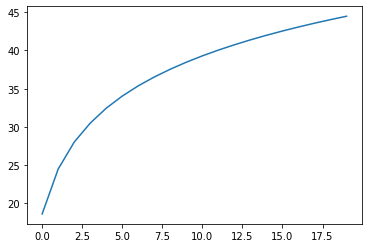

In [41]:
amplitude = np.abs(amps)/max(np.abs(amps))
yy = 20*np.log10(np.abs(amps))
plt.plot(yy)

In [43]:
filename = 'r2 ampdb'
# filename = 'r2_withoutamp 2'

filepath = os.path.join(database_path, filename)
hdf5_generator(
    filepath = filepath,
    x_info = {'name':'Frequency', 'unit':"MHz", 'values':pdrs},
    z_info = {'name': 'Signal','unit': 'a.u.','values': yy},
    comment = '', tag = f'OneTone'
)
upload_file2server(filepath=filepath+'.hdf5', server_ip=hostip, port=5000)

2024-11-19 05:04:20,065 - SR_Network:BlockingClient - Error: Connection refused


/home/xilinx/jupyter_notebooks/nthu/sinica-5q/Jay/Database/2024/11/Data_1115/r2 ampdb.hdf5 uploaded successfully


In [19]:
expt_cfg={"reps":1000, "round":1,"relax_delay":0,
          "start":6000, "stop":6010, "expts":201 }
pdr_cfg={"start":1000, "stop":20000, "expts":11}
config={**config,**expt_cfg, **pdr_cfg} #combine configs

fpts=np.linspace(expt_cfg["start"], expt_cfg["stop"], expt_cfg["expts"])
pdrs = np.linspace(pdr_cfg["start"], pdr_cfg["stop"], pdr_cfg["expts"])
config["readout_length"] = soc.us2cycles(0.5)
z=[]
outer_loop=tqdm(pdrs)
inner_loop=tqdm(fpts)
for g in (pdrs):
    config['res_gain']=int(g)
    amps=[]
    inner_loop.refresh()  #force print final state
    inner_loop.reset()  #reuse bar
    outer_loop.update() #update outer tqdm
    for f in (fpts):
        inner_loop.update()
        config["frequency"]=f
        rspec=SingleToneSpectroscopyProgram(soccfg, config)
        avgi,avgq=rspec.acquire(soc)
        amp=avgi[0][0]+1j*avgq[0][0]
        amps.append(amp)
    amps = np.array(amps)
    z.append(amps)
z = np.array(z)

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/201 [00:00<?, ?it/s]

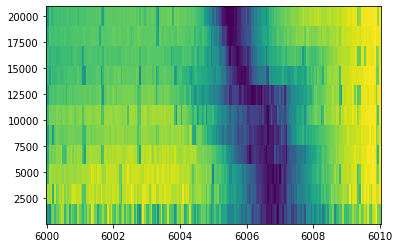

In [20]:
plt.figure()
zz=[]
for i in range(len(z)):
    zz.append(NormalizeData(np.abs(z[i])))
# plt.figure()
plt.pcolormesh(fpts,pdrs,np.abs(zz))

## SaveFile

In [80]:
filename = 'r2_pdr_amp_db'

filepath = os.path.join(database_path, filename)
hdf5_generator(
    filepath = filepath,
    x_info = {'name':'Frequency', 'unit':"Hz", 'values':fpts*1e6},
    z_info = {'name': 'Signal','unit': 'a.u.','values': z},
    y_info = {'name': 'power', 'unit': 'a.u.','values': pdrs},
    comment = 'reduce one room temp. amplifier', tag = f'OneTone/pdr'
)
upload_file2server(filepath=filepath+'.hdf5', server_ip=hostip, port=5000)

2024-10-14 05:48:23,982 - SR_Network:BlockingClient - Error: Connection refused


/home/xilinx/jupyter_notebooks/nthu/sinica-5q/Jay/Database/2024/10/Data_1014/r2_pdr_amp.hdf5 uploaded successfully


In [67]:
sys.path.append('/home/xilinx/jupyter_notebooks/nthu/Library')

# Flux dependent

In [191]:
from sqckit.labber_toolv2 import InstrManager
import pprint
a = InstrManager(server_ip=hostip)
a.add_instrument(sHardware='Yokogawa GS200 DC Source',
                    dComCfg={'name':'globalFlux',
                            'address': '0x0B21::0x0039::90ZB35282',
                            'interface': 'USB'})
yoko_cfg = {'Output': True,
            'Function': 'Current',
            'Range (I)': '10 mA',
           'Current - Sweep rate':10e-6}
a.ctrl.globalFlux.setInstrConfig(yoko_cfg)
sweep_rate = 10e-6
pprint.pprint(a.config)

Activate globalFlux successfully.
{'instruments': {'globalFlux': {'communication': {'address': '0x0B21::0x0039::90ZB35282',
                                                  'interface': 'USB'},
                                'description': 'You can write some purposes of '
                                               'globalFlux.',
                                'quantity': {'Current': 0.0,
                                             'Current - Sweep rate': 1e-05,
                                             'Function': 'Current',
                                             'Output': True,
                                             'Range (I)': '10 mA'},
                                'sHardware': 'Yokogawa GS200 DC Source'}},
 'server_ip': '192.168.10.252'}


In [192]:
# a.ctrl.globalFlux.setValue('Current', 0e-3, rate=sweep_rate)
a.ctrl.globalFlux.setValue('Current', -0.2e-3, rate=sweep_rate) 

-0.0002

  0%|          | 0/60 [00:00<?, ?it/s]

  0%|          | 0/401 [00:00<?, ?it/s]

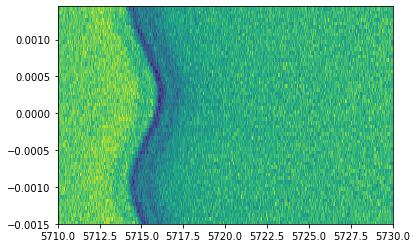

In [184]:
expt_cfg={"reps":2000, "rounds":1, "relax_delay":0, "start":5710, "stop":5730, "expts":401}
config={**config,**expt_cfg} #combine configs
config['res_gain'] = 3000

fpts = np.linspace(expt_cfg["start"], expt_cfg["stop"], expt_cfg['expts'])
flux = np.arange(-1.5e-3, 1.5e-3,5e-5)

z=[]
outer_loop=tqdm(flux)
inner_loop=tqdm(fpts)
for g in (flux):
    a.ctrl.globalFlux.setValue('Current', g, rate=sweep_rate)
    amps=[]
    inner_loop.refresh()  #force print final state
    inner_loop.reset()  #reuse bar
    outer_loop.update() #update outer tqdm
    for f in fpts:
        config["frequency"]=f
        rspec=SingleToneSpectroscopyProgram(soccfg, config)
        avgi,avgq=rspec.acquire(soc)
        amp=avgi[0][0]+1j*avgq[0][0]
        amps.append(amp)
        
        inner_loop.update()
    amps = np.array(amps)
    z.append(amps)
z = np.array(z)


plt.pcolormesh(fpts,flux,np.abs(z))

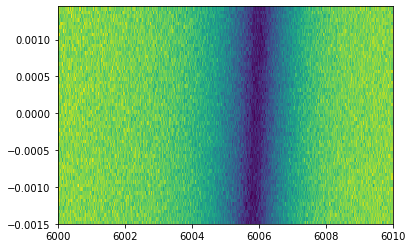

In [234]:
# plt.pcolormesh(fpts,flux,np.abs(z))

## SaveFile

In [185]:
filename = 'r1_flux'

filepath = os.path.join(database_path, filename)
comment = json.dumps(config, indent=4)

hdf5_generator(
    filepath = filepath,
    x_info = {'name':'Frequency', 'unit':"Hz", 'values':fpts*1e6},
    z_info = {'name': 'Signal','unit': 'a.u.','values': z},
    y_info = {'name': 'flux', 'unit': 'A','values': flux*1e3},
    comment = f'{comment}, tune q5 flux', 
    tag = f'OneTone'
)
upload_file2server(filepath=filepath+'.hdf5', server_ip=hostip, port=5000)

2024-08-13 06:00:21,557 - SR_Network:BlockingClient - Error: Connection refused


/home/xilinx/jupyter_notebooks/nthu/sinica-5q/Jay/Database/2024/08/Data_0813/r1_flux.hdf5 uploaded successfully


# correct the phase

  0%|          | 0/1001 [00:00<?, ?it/s]

relative delay -4.2128 us


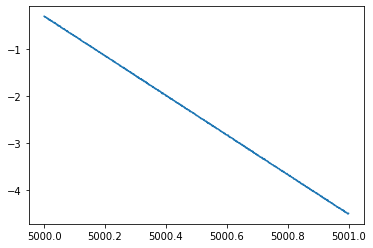

In [6]:
from tqdm.notebook import tqdm
expt_cfg={"reps":1000, "round":1,"relax_delay":0,
          "start":5000, "stop":5001, "expts":1001 }
config={**config,**expt_cfg} #combine configs
fpts=np.linspace(expt_cfg["start"], expt_cfg["stop"], expt_cfg["expts"])

amps=[]
for f in tqdm(fpts):
    config["frequency"]=f
    rspec=SingleToneSpectroscopyProgram(soccfg, config)
    avgi,avgq=rspec.acquire(soc)
    amp=np.array(avgi[0][0]+1j*avgq[0][0])
    amps.append(amp)
amps = np.array(amps)

phases = np.unwrap(np.angle(amps))/(2*np.pi)
plt.plot(fpts,phases)
a = np.vstack([fpts, np.ones_like(fpts)]).T
phase_delay = np.linalg.lstsq(a, phases, rcond=None)[0][0]
print("relative delay %.4f us"%(phase_delay))

  0%|          | 0/1001 [00:00<?, ?it/s]

Text(0, 0.5, 'phase [cycles]')

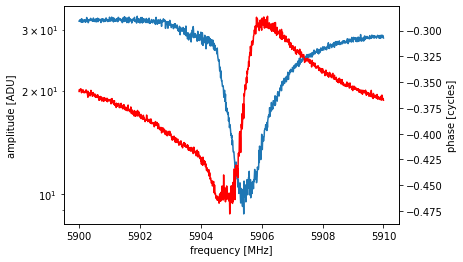

In [14]:
from tqdm.notebook import tqdm
expt_cfg={"reps":2000, "round":1,"relax_delay":0,
          "start":5900, "stop":5910, "expts":1001 }
config={**config,**expt_cfg} #combine configs
fpts=np.linspace(expt_cfg["start"], expt_cfg["stop"], expt_cfg["expts"])

amps2=[]

for f in tqdm(fpts):
    config["frequency"]=f
    rspec=SingleToneSpectroscopyProgram(soccfg, config)
    avgi,avgq=rspec.acquire(soc)
    amp=np.array(avgi[0][0]-1j*avgq[0][0])
    amps2.append(amp)
amps2 = np.array(amps2)

iq_rotated = amps2*np.exp(+1j*fpts*2*np.pi*phase_delay)
phases_corrected = np.unwrap(np.angle(iq_rotated))/(2*np.pi)
fig, plot = plt.subplots()
plot.semilogy(fpts, np.abs(iq_rotated), label="amplitude")
ax2 = plot.twinx()  # instantiate a second axes that shares the same x-axis
ax2.plot(fpts, phases_corrected, color='red', label='phase')
plot.set_ylabel("amplitude [ADU]")
plot.set_xlabel("frequency [MHz]")
ax2.set_ylabel("phase [cycles]")

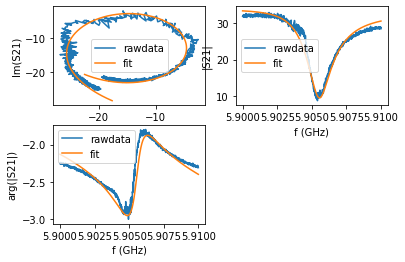

{'Qi_dia_corr': 6799.252707793826,
 'Qi_no_corr': 7077.152958436824,
 'absQc': 2727.900173758684,
 'Qc_dia_corr': 2771.564078500977,
 'Ql': 1968.9609556163339,
 'fr': 5905352193.815062,
 'theta0': -2.9643493343981513,
 'phi0': 0.17774019016800766,
 'phi0_err': 0.01581949141817427,
 'Ql_err': 30.466280029653156,
 'absQc_err': 24.38393462980171,
 'fr_err': 25898.77929309642,
 'chi_square': 0.004580240618907859,
 'Qi_no_corr_err': 324.9970803476129,
 'Qi_dia_corr_err': 300.9102945950898}

In [19]:
resonator_analyze(fpts*1e6, iq_rotated)

In [67]:
filename = 'r5 resonator correct phase'

filepath = os.path.join(database_path, filename)

hdf5_generator(
    filepath = filepath,
    x_info = {'name':'Frequency', 'unit':"GHz", 'values':fpts*1e6},
    z_info = {'name': 'Signal','unit': 'a.u.','values': iq_rotated},
    comment = '', 
    tag =f'onetone'
)
upload_file2server(filepath=filepath+'.hdf5', server_ip=hostip, port=5000)

2024-08-12 06:38:07,849 - SR_Network:BlockingClient - Error: Connection refused


/home/xilinx/jupyter_notebooks/nthu/sinica-5q/Jay/Database/2024/08/Data_0812/r5 resonator correct phase.hdf5 uploaded successfully


# Test fast flux

In [49]:
class SingleToneSpectroscopyProgram(AveragerProgram):
    def initialize(self):
        cfg=self.cfg   
        self.declare_gen(ch=cfg["res_ch"], nqz=2) #Readout
        self.declare_gen(ch=cfg["flux_ch"], nqz=1) #flux
        for ch in [0,1]: #configure the readout lengths and downconversion frequencies
            self.declare_readout(ch=ch, length=cfg["readout_length"],
                                 freq=cfg["frequency"], gen_ch=cfg["res_ch"])
        
        freq=self.freq2reg(cfg["frequency"], gen_ch=cfg["res_ch"], ro_ch=0)  # convert frequency to dac frequency (ensuring it is an available adc frequency)
        self.set_pulse_registers(ch=cfg["res_ch"], style="const", freq=freq, phase=0, gain=cfg["res_gain"],
                                length=cfg["readout_length"])
        
        self.set_pulse_registers(ch=cfg["flux_ch"], style='const', freq=0, phase=0, gain=cfg["flux_gain"], 
                                 length=cfg["length"])
        self.synci(200)  # give processor some time to configure pulses
    
    def body(self):
        self.pulse(ch=self.cfg['flux_ch'])
        self.synci(self.cfg['saturate'])
        self.measure(pulse_ch=self.cfg["res_ch"], 
             adcs=[0,1],
             adc_trig_offset=self.cfg["adc_trig_offset"],
             wait=True,
             syncdelay=self.us2cycles(self.cfg["relax_delay"]))     

In [52]:
config={"res_ch":0, # --Fixed
        "ro_chs":0, # --Fixed
        "reps":1, # --Fixed
        "relax_delay":2.0, # --us
        "res_phase":0, # --degrees
        "readout_length":soc.us2cycles(1), 
        "res_gain":2000, 
        "frequency": 5000, 
        "adc_trig_offset": soc.us2cycles(0.4),
        "soft_avgs":1,
        
        
        "flux_ch":5,
        "flux_gain": -20000,
        "length": soc.us2cycles(5),
        "sigma":soc.us2cycles(0.01),
        #keep this two value when sweep flux vs resonator
        "saturate":soc.us2cycles(2)
       }

  0%|          | 0/201 [00:00<?, ?it/s]

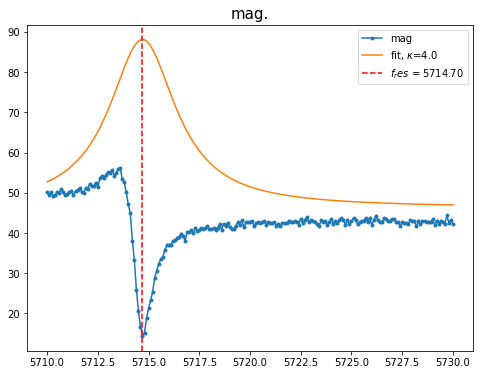

5714.7

In [53]:
##### from tqdm.notebook import tqdm
expt_cfg={ "start":5710, "stop":5730, "expts":201, "reps":1000,  "relax_delay":3 }
config={**config,**expt_cfg} #combine configs
fpts=np.linspace(expt_cfg["start"], expt_cfg["stop"], expt_cfg["expts"])

amps=[]
for f in tqdm(fpts):
    config["frequency"]=f
    rspec=SingleToneSpectroscopyProgram(soccfg, config)
    avgi,avgq=rspec.acquire(soc)
    amp=np.array(avgi[0][0]+1j*avgq[0][0])
    amps.append(amp)
amps = np.array(amps)

resonator_analyze2(fpts, np.abs(amps), fit=True)

In [56]:
##### from tqdm.notebook import tqdm
expt_cfg={"reps":1000, "round":1,"relax_delay":0,"start":5713, "stop":5717, "expts":101 }
config={**config,**expt_cfg} #combine configs
fpts=np.linspace(expt_cfg["start"], expt_cfg["stop"], expt_cfg["expts"])

gain = np.arange(-30000,40000, 5000)
z = []
outer_loop=tqdm(gain)
inner_loop=tqdm(fpts)
for g in gain:
    inner_loop.refresh()  #force print final state
    inner_loop.reset()  #reuse bar
    outer_loop.update() #update outer tqdm
    config['flux_gain'] = g
    amps=[]
    for f in fpts:
        config["frequency"]=f
        rspec=SingleToneSpectroscopyProgram(soccfg, config)
        avgi,avgq=rspec.acquire(soc)
        amp=np.array(avgi[0][0]+1j*avgq[0][0])
        amps.append(amp)
        inner_loop.update()
    amps = np.array(amps)
    z.append(amps)

  0%|          | 0/14 [00:00<?, ?it/s]

  0%|          | 0/101 [00:00<?, ?it/s]

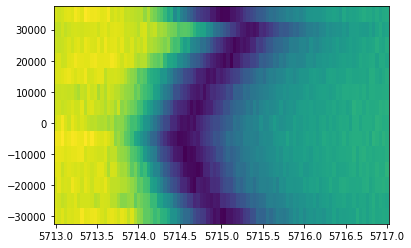

In [57]:
plt.figure(facecolor='white',edgecolor='black')
plt.pcolormesh(fpts, np.array(gain), np.abs(z))

In [59]:
filename = 'r1_dc_flux_onetone'

filepath = os.path.join(database_path, filename)

hdf5_generator(
    filepath = filepath,
    x_info = {'name':'Frequency', 'unit':"Hz", 'values':fpts*1e6},
    z_info = {'name': 'Signal','unit': 'a.u.','values': z},
    y_info = {'name': 'flux_gain', 'unit': 'a.u', 'values': (gain)},
    comment = f'', 
    tag = f'OneTone'
)
upload_file2server(filepath=filepath+'.hdf5', server_ip=hostip, port=5000)

2024-10-11 04:52:06,022 - SR_Network:BlockingClient - Error: Connection refused


/home/xilinx/jupyter_notebooks/nthu/sinica-5q/Jay/Database/2024/10/Data_1011/r1_dc_flux_onetone.hdf5 uploaded successfully
